# =====================================================
# HEART DISEASE PREDICTION USING ML CLASSIFIERS
# Decision Tree, SVM, and k-NN
# =====================================================


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [2]:
# Load Dataset

df = pd.read_csv("/content/heart_disease_data.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape: (1025, 14)

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [3]:
# Input and Output Variables

X = df.drop("target", axis=1)
y = df["target"]


In [4]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# DECISION TREE

dt_model = DecisionTreeClassifier(random_state=42)

dt_params = {
    'max_depth': [3, 5, 7, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(
    dt_model,
    dt_params,
    cv=5,
    scoring='accuracy'
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

In [6]:
# SVM

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

svm_params = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=5,
    scoring='accuracy'
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_



In [7]:
# KNN


knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=5,
    scoring='accuracy'
)

knn_grid.fit(X_train, y_train)

best_knn = knn_grid.best_estimator_



In [8]:

# Evaluation Function


def evaluate_model(model, model_name):

    y_pred = model.predict(X_test)

    # Probability prediction for ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("\n===================================")
    print(f"{model_name} Results")
    print("===================================")

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC AUC  :", roc_auc)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # -----------------------------
    # ROC Curve
    # -----------------------------
    fpr, tpr, threshold = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

    plt.plot([0,1], [0,1], linestyle='--')

    plt.title(f"{model_name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()

    return accuracy, precision, recall, f1, roc_auc




Decision Tree Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



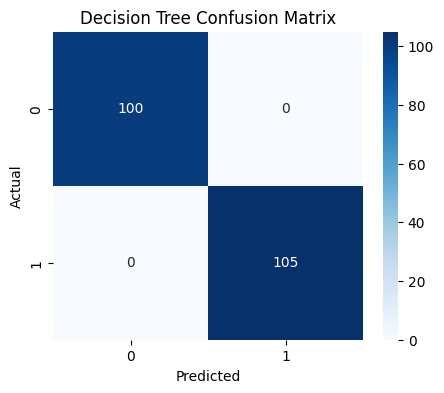

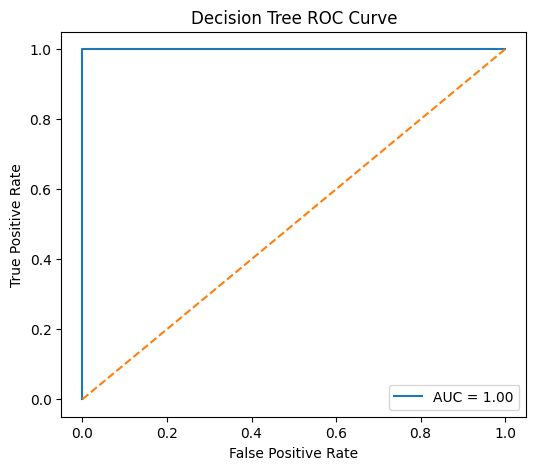


SVM Results
Accuracy : 0.9853658536585366
Precision: 0.9722222222222222
Recall   : 1.0
F1 Score : 0.9859154929577465
ROC AUC  : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       100
           1       0.97      1.00      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.98      0.99       205
weighted avg       0.99      0.99      0.99       205



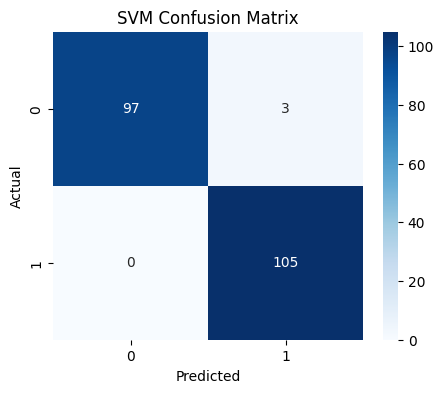

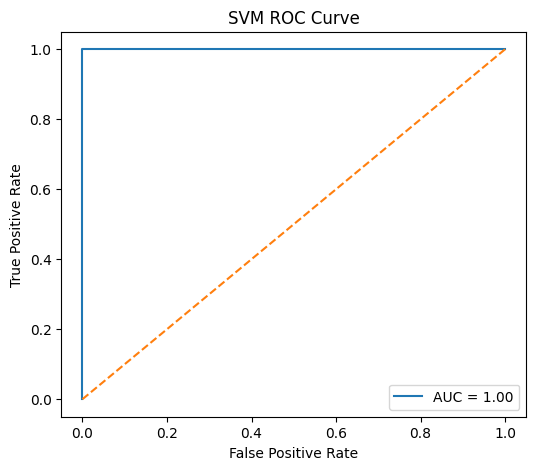


k-NN Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC AUC  : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



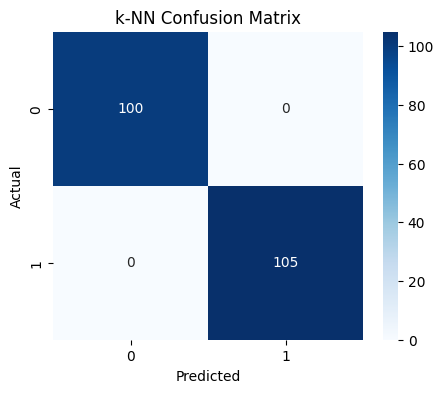

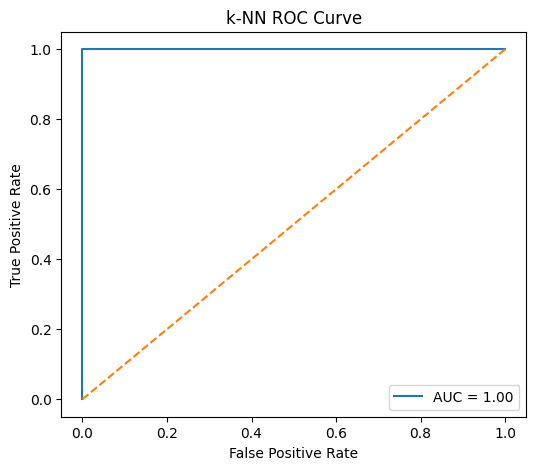

In [9]:
# Evaluate Models


dt_results = evaluate_model(best_dt, "Decision Tree")

svm_results = evaluate_model(best_svm, "SVM")

knn_results = evaluate_model(best_knn, "k-NN")



In [10]:
# Final Comparison Table


results_df = pd.DataFrame({
    'Model': ['Decision Tree', 'SVM', 'k-NN'],
    'Accuracy': [dt_results[0], svm_results[0], knn_results[0]],
    'Precision': [dt_results[1], svm_results[1], knn_results[1]],
    'Recall': [dt_results[2], svm_results[2], knn_results[2]],
    'F1 Score': [dt_results[3], svm_results[3], knn_results[3]],
    'ROC AUC': [dt_results[4], svm_results[4], knn_results[4]]
})

print("\n==============================")
print("FINAL MODEL COMPARISON")
print("==============================")

print(results_df)



FINAL MODEL COMPARISON
           Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Decision Tree  1.000000   1.000000     1.0  1.000000      1.0
1            SVM  0.985366   0.972222     1.0  0.985915      1.0
2           k-NN  1.000000   1.000000     1.0  1.000000      1.0


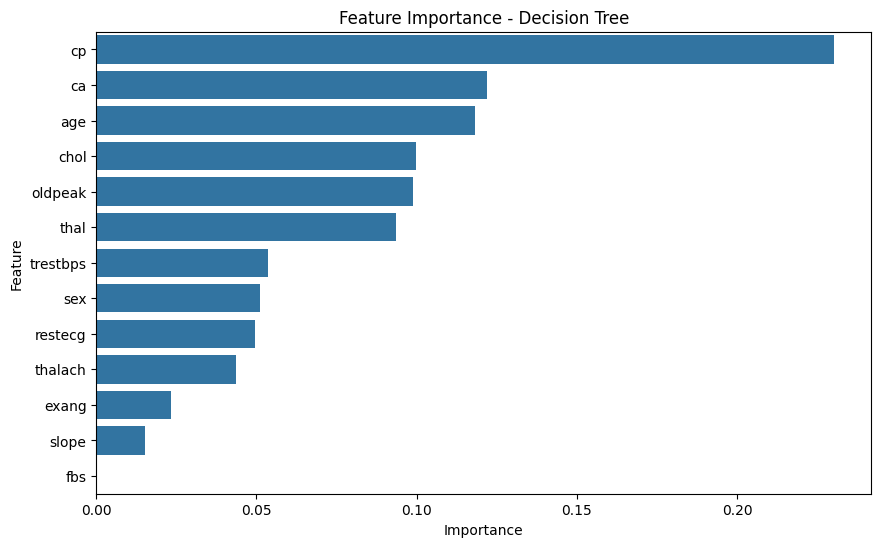

In [11]:
# Feature Importance (Advancement)


feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Decision Tree")

plt.show()